# 07. Transformer Architecture

<div style="margin:.3rem 0 1rem;font-size:.9em;color:#555;display:flex;align-items:center;gap:.35rem;font-family:monospace">
  <time datetime="2026-04-16">16 Apr 2026</time> /
  <time datetime="2026-04-18">18 Apr 2026</time>
</div>

<a href="https://colab.research.google.com/github/shahaliyev/csci4701/blob/main/docs/notebooks/07_transformer.ipynb"
   target="_blank" rel="noopener">
  <img
    src="https://colab.research.google.com/assets/colab-badge.svg"
    alt="Open in Colab"
  />
</a>

<div class="admonition info">
  <p class="admonition-title">Info</p>
  <p style="margin: 0.5em 0;">
    The following source was consulted in preparing this material:
  </p>
  <ul style="margin-top: 0;">
    <li>
      Zhang, A., Lipton, Z. C., Li, M., &amp; Smola, A. J.
      <a href="https://d2l.ai/">Dive into Deep Learning</a>. Cambridge University Press.
      <a href="https://d2l.ai/chapter_attention-mechanisms-and-transformers/index.html">Attention Mechanisms and Transformers</a>.
    </li>
  </ul>
</div>

This notebook builds the Transformer architecture step by step following the infamous _Attention is all you need_ ([Vaswani et al., 2017](https://arxiv.org/abs/1706.03762)) paper. We begin with the limitation of fixed-context sequence-to-sequence models, move to attention as weighted retrieval, discuss self-attention, assemble multi-head attention, feed-forward layers, residual connections and normalization, the encoder block, the decoder block, and finally the full training and inference of Transformers.

## Attention

In the classical [encoder-decoder](../06_rnn_sequential#encoder-decoder-architecture) view of [sequence modeling](../06_rnn_sequential/#language-modeling), the encoder reads the whole source sequence and compresses it into one context vector:
$$
c = \operatorname{Encoder}(x_1, x_2, \dots, x_T),
\qquad
y_t = \operatorname{Decoder}(y_{<t}, c).
$$

<figure>
  <img src="../../assets/images/transformer/seq2seq-state.svg" alt="Sequence to Sequence (Seq2Seq) Layers" style="max-width: 100%; height: auto;">
  <figcaption style="margin-top: 0.5em; font-size: 0.9em; opacity: 0.85;">
    Sequence-to-sequence (Seq2Seq) learning layers in encoder-decoder architecture. The state (context), as generated by the encoder, is the only piece of information shared between the encoder and the decoder. ~ Zhang et al., <a href="https://d2l.ai/chapter_attention-mechanisms-and-transformers/bahdanau-attention.html">Dive into Deep Learning</a>, <a href="https://d2l.ai/_images/seq2seq-state.svg">Fig. 11.4.1</a>.
    <a href="https://creativecommons.org/licenses/by-sa/4.0/">CC BY-SA 4.0</a>.
  </figcaption>
</figure>

This is elegant, but it creates a bottleneck. The same vector $c$ must carry whatever information the decoder may need at every later step. For short inputs that can be enough. For longer or more detailed inputs, it is restrictive because the decoder cannot change what it retrieves from the source: it only keeps reusing the same summary. [Attention](<https://en.wikipedia.org/wiki/Attention_(machine_learning)>) changes this. Instead of one frozen context, the decoder modifies context depending on a step:
$$
c_t = \sum_{i=1}^{T} \alpha_{t,i} h_i,
$$
where $h_i$ is the encoder representation at source position $i$ and $\alpha_{t,i}$ says how strongly step $t$ should use that position. So the model no longer asks the encoder for one final summary: it asks for a new weighted summary whenever the current prediction step needs one.  From a [linear algebra](../../mathematics/02_linear_algebra) point of view, attention is just learned weighted averaging. From a modeling point of view, it removes the fixed-summary bottleneck because the summary can change from one prediction step to the next. The next section will formalize this mechanism using the language of queries, keys, and values.

## Query, Key, Value

The formula from the previous section says that the decoder no longer uses the same frozen summary at every step. To make that idea precise, we now separate three roles. The current need of the model is represented by a *query*. The source (encoder)-side items that can be matched against that need are represented by *keys*. The actual pieces of information that will be mixed together are represented by *values*. Hence, attention is explained through the language of a database: a query is compared against keys, and the result tells us how strongly to retrieve the corresponding values. If the source-side collection is $D = \{(k_1, v_1), \dots, (k_m, v_m)\}$, then attention produces
$$
\operatorname{Attn}(q, D) = \sum_{i=1}^{m} \alpha(q, k_i) v_i.
$$
Here $q$ is the query, $k_i$ is the key for item $i$, $v_i$ is its value, and $\alpha(q, k_i)$ is the weight assigned to that item. So attention does not directly output one source vector. It outputs a weighted combination of values. The next two cells make this concrete with one query and four key-value pairs. The values are chosen to be especially easy to inspect, so the mechanics are visible before we move to the full matrix form.

In [1]:
import torch

tokens = ["the", "cat", "sat", "down"]

k = torch.tensor([[0.0], [1.0], [2.0], [3.0]])
v = torch.tensor([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0], [0.5, 0.5]])
q = torch.tensor([1.5])

scores = q @ k.T
scores

tensor([0.0000, 1.5000, 3.0000, 4.5000])

<figure>
  <img src="../../assets/images/transformer/qkv.svg" alt="Sequence to Sequence (Seq2Seq) Layers" style="max-width: 100%; height: auto;">
  <figcaption style="margin-top: 0.5em; font-size: 0.9em; opacity: 0.85;">
    The attention mechanism computes a linear combination over values via attention pooling, where weights are derived according to the compatibility between a query and keys ~ Zhang et al., <a href="https://d2l.ai/chapter_attention-mechanisms-and-transformers/queries-keys-values.html">Dive into Deep Learning</a>, <a href="https://d2l.ai/_images/qkv.svg">Fig. 11.1.1</a>.
    <a href="https://creativecommons.org/licenses/by-sa/4.0/">CC BY-SA 4.0</a>.
  </figcaption>
</figure>

Because the keys are one-dimensional, the score for each item is just the product of the scalar query and the corresponding scalar key. So each raw score tells us how strongly the current query matches that item under this simple scoring rule. Larger scores mean a stronger match. To turn these raw scores into usable attention weights, we normalize them with the [softmax function](../../mathematics/03_probability/#softmax), which converts the scores into nonnegative weights that sum to one. These weights are then used to form a [convex combination](https://en.wikipedia.org/wiki/Convex_combination) of the values.

In [2]:
weights = torch.softmax(scores, dim=0)
context = weights @ v

weights, context

(tensor([0.0087, 0.0388, 0.1738, 0.7788]), tensor([0.5718, 0.6019]))

The result is easier to interpret here because we deliberately chose simple values whose coordinates can be inspected directly. The context vector is formed by weighting each value according to the attention weights and then summing the result. That is a general mechanism of attention. The query places most weight on the third and fourth items, so the resulting context is influenced mostly by their values. This is the basic role of queries, keys, and values in attention: _the query says what the model is looking for now, the keys determine how strongly each item matches that need, and the values are the vectors that are actually combined._

## Masked Attention

We should note one important nuance here. Attention usually runs on batches of sequences, and those sequences often have different lengths. To place them in the same batch, we pad the shorter ones, similar to what we saw in the RNN lecture. As padded positions are not real tokens, attention should not assign weight to them. That is why we may need a **masked** version of the softmax function. If only the first $\ell$ positions are valid, then the masked version should normalize over those positions only and force the rest to zero:
$$
\alpha_i = \frac{e^{s_i}}{\sum_{j=1}^{\ell} e^{s_j}} \text{ for } i \leq \ell,
\qquad
\alpha_i = 0 \text{ for } i > \ell.
$$

In [3]:
# 0.0 represents padding here
scores = torch.tensor([
    [2.0, 1.0, 0.0, 0.0],
    [0.3, 1.4, 0.2, 0.0],
])

torch.softmax(scores, dim=-1)

tensor([[0.6103, 0.2245, 0.0826, 0.0826],
        [0.1770, 0.5317, 0.1602, 0.1311]])

Even though the first example should only use its first two positions and the second example should only use its first three, vanilla softmax still spreads some weight onto the padded positions. In a model it would allow meaningless padding tokens to influence the context vector. So we need to hide positions beyond the valid length before softmax is applied. The usual trick is simple: replace masked entries by a very large negative number. After exponentiation inside softmax, those entries contribute essentially zero.

In [4]:
valid_lens = torch.count_nonzero(scores, dim=-1)
mask = torch.arange(scores.size(-1)) < valid_lens.unsqueeze(1)
masked_scores = scores.masked_fill(~mask, float('-inf')) # ~ is "not" operator

mask, masked_scores

(tensor([[ True,  True, False, False],
         [ True,  True,  True, False]]),
 tensor([[2.0000, 1.0000,   -inf,   -inf],
         [0.3000, 1.4000, 0.2000,   -inf]]))

In [5]:
weights = torch.softmax(masked_scores, dim=-1)
weights

tensor([[0.7311, 0.2689, 0.0000, 0.0000],
        [0.2037, 0.6120, 0.1843, 0.0000]])

Now the padded positions receive zero weight, while the valid positions are renormalized to sum to $1$. This is the form we will use from now on. In later Transformer code, attention scores will usually appear as matrices or batches of matrices rather than small vectors, but the same masking idea still applies.

## Similarity Kernels

Before learning attention weights, it helps to see the same idea in a simpler form. Suppose we already know how to measure similarity between a query and each key. Then we can turn those similarities into weights and use them to compute a weighted average of the values. A simple example is house price prediction by location. Suppose the *query* is the location of a new house whose price we want to estimate. The *keys* are the locations of houses we have already seen, and the *values* are their prices. Then nearby houses should influence our estimate more than faraway houses. So we compare the query location with each known location, assign larger weights to more similar locations, and take a weighted average of the known prices. If the query is $q$, the keys are $k_1,\dots,k_m$, and the values are $v_1,\dots,v_m$, we can write
$$
\hat{v}(q) = \frac{\sum_{i=1}^m \alpha(q, k_i)\, v_i}{\sum_{i=1}^m \alpha(q, k_i)}.
$$
Here $\alpha(q, k_i)$ is a hand-crafted similarity score. If a key is closer to the query, it receives a larger weight. So this is already very close to attention. The main difference is that the scoring rule is fixed by us rather than learned by the model. The next cell shows two simple similarity kernels:

$$
\alpha_{\text{gaussian}}(q, k) = \exp\!\left(-\frac{(q-k)^2}{2\sigma^2}\right)
\\\\
\alpha_{\text{boxcar}}(q, k) =
\begin{cases}
1, & |q-k| < 1 \\
0, & \text{otherwise.}
\end{cases}
$$

 The [Gaussian kernel](https://en.wikipedia.org/wiki/Gaussian_function) decreases smoothly as the query and key move apart. The [boxcar kernel](https://en.wikipedia.org/wiki/Boxcar_function) is even simpler: it gives weight $1$ to nearby keys and $0$ to keys that are too far away. We will use the same house-price example. First, let us define the query, keys, and values. Here the locations are one-dimensional just to keep the example simple. We will also define kernels.

In [6]:
keys = torch.tensor([1, 2, 5, 3, 10, 1]) # known locations (input)
values = torch.tensor([100, 120, 75, 90, 130, 95], dtype=torch.float32) # prices (label)
query = torch.tensor(2.0) # location for which we need to predict price

def gaussian(q, k, sigma=1.0):
    return torch.exp(-((q - k) ** 2) / (2 * sigma ** 2))

def boxcar(q, k):
    return (torch.abs(q - k) < 1.0).to(torch.float32)

Next, we compute one similarity score for each key. These scores tell us how much each known house should influence the prediction. Once we have the scores, we turn them into a weighted average of the values, meaning that values with larger similarity scores contribute more to the final estimate. We follow the formula introduced above.

In [7]:
gaussian_scores = gaussian(query, keys)
boxcar_scores = boxcar(query, keys)

gaussian_pred = (gaussian_scores * values).sum() / gaussian_scores.sum()
boxcar_pred = (boxcar_scores * values).sum() / boxcar_scores.sum()

round(gaussian_pred.item(), 3), round(boxcar_pred.item(), 3)

(103.753, 120.0)

This is already very close to attention. The only major difference is that here the weighting rule (similarity kernel) is fixed by us. In neural attention, the model learns how to produce these weights from data.

## Bahdanau Attention

<figure>
  <img src="../../assets/images/transformer/bahdanau.svg" alt="Bahdanau Attention" style="max-width: 100%; height: auto;">
  <figcaption style="margin-top: 0.5em; font-size: 0.9em; opacity: 0.85;">
    Layers in an RNN encoder–decoder model with the Bahdanau attention mechanism. ~ Zhang et al., <a href="https://d2l.ai/chapter_attention-mechanisms-and-transformers/bahdanau-attention.html">Dive into Deep Learning</a>, <a href="https://d2l.ai/_images/seq2seq-details-attention.svg">Fig. 11.4.2</a>.
    <a href="https://creativecommons.org/licenses/by-sa/4.0/">CC BY-SA 4.0</a>.
  </figcaption>
</figure>

The previous section used fixed similarity kernels such as the Gaussian kernel. That helps build intuition, but in a neural network we usually do not want to hand-design the scoring rule. We want the model to learn which keys matter for a given query. Bahdanau attention ([Bahdanau et al., 2014](https://arxiv.org/abs/1409.0473)) integrates attention mechanism to seq2seq modeling. The idea is that, in encoder-decoder translation models, the encoder produces a sequence of hidden states $h_1,\dots,h_m$, and at decoder step $t$ the model computes an alignment score between the current decoder state $s_{t-1}$ and each encoder state $h_i$:
$$
e_{t,i} = v^\top \tanh(W_s s_{t-1} + W_h h_i).
$$
These scores are then normalized with softmax:
$$
\alpha_{t,i} = \frac{\exp(e_{t,i})}{\sum_j \exp(e_{t,j})},
\qquad
c_t = \sum_i \alpha_{t,i} h_i.
$$

Here $c_t$ is the context vector passed to the decoder. So unlike fixed kernels, the scoring function is learned from data. This is often called additive attention, because the score is produced by combining transformed versions of the query and key and then passing them through a small neural layer. This is conceptually close to modern attention: compare a query against many keys, turn the scores into weights, and take a weighted sum of values. The main difference is that Bahdanau attention uses a learned feed-forward scoring function, whereas the Transformer uses scaled dot products, which are simpler and much easier to parallelize efficiently.

## Scaled Dot-Product Attention

The earlier section explained what queries ($q$), keys ($k$), and values ($v$) are, and it also showed why padded positions must be hidden before softmax. We can now complete the picture by writing the rule that turns a query and a set of keys into attention scores. In modern Transformer models, the standard rule is *scaled dot-product attention* ([Vaswani et al., 2017](https://arxiv.org/abs/1706.03762)). Simply, the raw compatibility scores are computed with the dot product:
$$
s_i = q^\top k_i.
$$
This is a natural similarity score. If $q$ and $k_i$ point in similar directions, the dot product is large. If they disagree, it is smaller or even negative. To turn these raw scores into attention weights, we apply softmax. However, we do not use $q^\top k_i$ directly. We divide by $\sqrt{d}$, where $d$ is the key dimension:
$$
\alpha_i = \frac{\exp\!\left(q^\top k_i / \sqrt{d_k}\right)}{\sum_{j=1}^{m} \exp\!\left(q^\top k_j / \sqrt{d_k}\right)}.
$$
The scaling matters because dot products usually grow in magnitude as the dimension grows. If we fed very large scores directly into softmax, the resulting weights could become too sharp too early. Dividing by $\sqrt{d_k}$ keeps the scale more stable.

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
  Dot-product attention is not as different from Gaussian similarity as it first appears. If we start from the Gaussian score and expand the squared distance, we get
  
  <div style="overflow-x:auto; max-width:100%; margin:-0.4rem 0;">
  $$
  a(q, k_i)
  = -\frac{1}{2}\big(\|q\|^2 + \|k_i\|^2 - 2q^\top k_i\big)
  = q^\top k_i - \frac{1}{2}\|q\|^2 - \frac{1}{2}\|k_i\|^2.
  $$
  </div>
  So the dot product $q^\top k_i$ is already hidden inside the Gaussian kernel. Moreover, for a fixed query $q$, the term $-\frac{1}{2}\|q\|^2$ is the same for every key, so it does not affect which key receives more attention after softmax. If the key norms $k_i$ are also roughly similar, then the main part controlling the ranking is just the alignment term $q^\top k_i$. This is why dot-product attention can be viewed as a simpler and more direct form of similarity scoring.
  </p>
</div>

In [8]:
d = torch.tensor(masked_scores.size(-1))
scaled_scores = masked_scores / torch.sqrt(d)
scaled_weights = torch.softmax(scaled_scores, dim=-1)

weights, scaled_weights

(tensor([[0.7311, 0.2689, 0.0000, 0.0000],
         [0.2037, 0.6120, 0.1843, 0.0000]]),
 tensor([[0.6225, 0.3775, 0.0000, 0.0000],
         [0.2714, 0.4704, 0.2582, 0.0000]]))

If the components of $q$ and $k$ are independent with mean $0$ and variance $1$, then the dot product still has mean $0$, but its variance grows with $d_k$. So when $d_k$ becomes large, the raw attention scores tend to spread out more. After softmax, that wider spread often makes the distribution too sharp: one or two positions get almost all the weight, while the others get almost none. That is bad for optimization because the gradients become less informative. This is the motivation given in the original Transformer paper. It should distantly resemble [weight initialization](../04_regul_optim/#weight-initialization) and [batch normalization](../05_cnn_architectures/#batch-normalization).

In [9]:
var = []
scaled_var = []

for d in [4, 16, 64, 256]:
    q = torch.randn(1000, d)
    k = torch.randn(1000, d)

    scores = (q * k).sum(dim=-1)
    scaled_scores = scores / torch.sqrt(torch.tensor(d))

    var.append(scores.var(unbiased=False))
    scaled_var.append(scaled_scores.var(unbiased=False))

var, scaled_var

([tensor(4.1513), tensor(15.9876), tensor(64.4055), tensor(248.5805)],
 [tensor(1.0378), tensor(0.9992), tensor(1.0063), tensor(0.9710)])

We can now write attention in matrix form. Suppose $Q$ is a matrix of queries, $K$ is a matrix of keys, and $V$ is a matrix of values. Then scaled dot-product attention is
$$
\operatorname{Attn}(Q, K, V) = \operatorname{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right)V.
$$
The product $QK^\top$ computes many dot products at once, so every query is compared with every key. Softmax turns each row of raw scores into attention weights. Multiplying by $V$ then forms the weighted sums of the values. The next cell uses a tiny batched example so that we can see the weights and resulting context vectors explicitly before moving on to larger Transformer blocks. Below, the tensor `weights` tells us how strongly each query attends to each key, and `attention` (context) is the weighted sum of the values.

In [10]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    d = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / (d ** 0.5)
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))
    weights = torch.softmax(scores, dim=-1)
    return weights @ V, weights

Q = torch.tensor([
    [[1.0, 0.0], [0.0, 1.0]],
    [[1.0, 1.0], [1.0, 0.0]],
])

K = torch.tensor([
    [[1.0, 0.0], [0.0, 1.0], [1.0, 1.0], [0.0, 0.5]],
    [[1.0, 1.0], [0.0, 1.0], [1.0, 0.0], [5.0, 5.0]],
])

V = torch.tensor([
    [[10.0, 0.0], [0.0, 10.0], [5.0, 5.0], [2.0, 8.0]],
    [[1.0, 1.0], [0.0, 2.0], [2.0, 0.0], [9.0, 9.0]],
])

attention, weights = scaled_dot_product_attention(Q, K, V)

Q.shape, K.shape, V.shape

(torch.Size([2, 2, 2]), torch.Size([2, 4, 2]), torch.Size([2, 4, 2]))

In [11]:
weights, weights.shape

(tensor([[[0.3349, 0.1651, 0.3349, 0.1651],
          [0.1543, 0.3130, 0.3130, 0.2198]],
 
         [[0.0035, 0.0017, 0.0017, 0.9931],
          [0.0515, 0.0254, 0.0515, 0.8716]]]),
 torch.Size([2, 2, 4]))

In [12]:
attention, attention.shape

(tensor([[[5.3534, 4.6466],
          [3.5475, 6.4525]],
 
         [[8.9449, 8.9449],
          [7.9987, 7.9464]]]),
 torch.Size([2, 2, 2]))

## Multi-Head Attention

_Scaled dot-product attention_ gives one set of attention weights and one weighted sum of values. That is already useful, but in language modeling a single attention pattern is often too limited. When predicting the next token, the model may need to track different kinds of information at the same time. One part may need to focus on the most recent word, another on a subject from several positions earlier, and another on the token that should agree in tense, number, or meaning. This is the idea behind *multi-head attention*: instead of computing attention once, we compute it several times in parallel on different learned versions of the same input, then combine the results. A compact way to write this is
$$
\text{head}_i=\operatorname{Attn}(Q_i,K_i,V_i)
\\\\
\operatorname{MHA}(Q,K,V)=\operatorname{Concat}(\text{head}_1,\dots,\text{head}_h).
$$

This says that each head gets its own projected queries, keys, and values, performs attention separately, and produces its own output. We then concatenate the outputs of all heads. So one head gives one way to attend, while multiple heads let the model look at the same sequence in several ways at once.

<figure>
  <img src="../../assets/images/transformer/multi-head-attention.svg" alt="Miltihead Attention" style="max-width: 100%; height: auto;">
  <figcaption style="margin-top: 0.5em; font-size: 0.9em; opacity: 0.85;">
    Multi-head attention, where multiple heads are concatenated then linearly transformed. ~ Zhang et al., <a href="https://d2l.ai/chapter_attention-mechanisms-and-transformers/multihead-attention.html">Dive into Deep Learning</a>, <a href="https://d2l.ai/_images/seq2seq-details-attention.svg">Fig. 11.5.1</a>.
    <a href="https://creativecommons.org/licenses/by-sa/4.0/">CC BY-SA 4.0</a>.
  </figcaption>
</figure>

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
    For example, in a sentence like <em>The cats on the sofa are sleeping</em>, one head might focus on nearby tokens such as <em>are</em> and <em>sleeping</em>, while another might connect <em>cats</em> with <em>are</em>. In a sequence like <em>I grew up in Azerbaijan, so I speak fluent ...</em>, one head may focus on the most recent phrase, while another attends back to <em>Azerbaijan</em>. We should not think of heads as manually assigned grammar rules, but these examples give the right intuition: different heads can specialize in different useful patterns.
  </p>
</div>


In [13]:
X = torch.tensor([[
    [2.0, 0.0, 0.0, 0.0],
    [1.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 2.0, 0.0],
    [0.0, 0.0, 1.0, 1.0],
]])

Q1 = K1 = V1 = X[:, :, :2]
Q2 = K2 = V2 = X[:, :, 2:]

head1, weights1 = scaled_dot_product_attention(Q1, K1, V1)
head2, weights2 = scaled_dot_product_attention(Q2, K2, V2)

weights1[0], weights2[0]

(tensor([[0.7346, 0.1786, 0.0434, 0.0434],
         [0.4022, 0.4022, 0.0978, 0.0978],
         [0.2500, 0.2500, 0.2500, 0.2500],
         [0.2500, 0.2500, 0.2500, 0.2500]]),
 tensor([[0.2500, 0.2500, 0.2500, 0.2500],
         [0.2500, 0.2500, 0.2500, 0.2500],
         [0.0434, 0.0434, 0.7346, 0.1786],
         [0.0978, 0.0978, 0.4022, 0.4022]]))

This example is artificial on purpose. The first head only sees the first two coordinates, and the second head only sees the last two. So the two heads look at different parts of the same token representation. That is why they produce different attention patterns. In a real Transformer, these projections are not chosen by hand like this and are learned during training. But the effect is the same: different heads can focus on different relationships.

In [14]:
multi_head_output = torch.cat([head1, head2], dim=-1)
multi_head_output, multi_head_output.shape

(tensor([[[1.6477, 0.1786, 0.7500, 0.2500],
          [1.2066, 0.4022, 0.7500, 0.2500],
          [0.7500, 0.2500, 1.6477, 0.1786],
          [0.7500, 0.2500, 1.2066, 0.4022]]]),
 torch.Size([1, 4, 4]))

The concatenated output has four features again, because we joined two heads of width 2 each. This is the basic structure of multi-head attention: split the representation into several smaller views, run attention separately, then join the results back together.

## Self-Attention

We can now look at the most important special case of multi-head attention. In *self-attention*, the queries, keys, and values all come from the same sequence. If the input sequence is represented by $X$, then the idea is written compactly as
$$
\operatorname{SelfAttn}(X)=\operatorname{Attn}(X,X,X).
$$
This means that each token forms a query, compares itself with every token in the same sequence, and then builds a new representation as a weighted sum of those token vectors. In language modeling, this is exactly what we want. When processing a token such as *sat*, the model may need to look at nearby words, earlier words, or even the token itself. Self-attention gives every token direct access to the whole sequence in one step.

In [15]:
self_attention, self_weights = scaled_dot_product_attention(X, X, X)
self_weights[0], self_attention[0]

(tensor([[0.6103, 0.2245, 0.0826, 0.0826],
         [0.3655, 0.3655, 0.1345, 0.1345],
         [0.0826, 0.0826, 0.6103, 0.2245],
         [0.1345, 0.1345, 0.3655, 0.3655]]),
 tensor([[1.4451, 0.2245, 0.2478, 0.0826],
         [1.0966, 0.3655, 0.4034, 0.1345],
         [0.2478, 0.0826, 1.4451, 0.2245],
         [0.4034, 0.1345, 1.0966, 0.3655]]))

The attention weights are easiest to read row by row. Each row corresponds to one query token, and each column corresponds to one key token. So row $i$ tells us how the $i$-th token distributes its attention across the full sequence. The output still has the same number of tokens as the input, but now each token representation has been updated using information from the others. This is the key difference from a recurrent model: instead of passing information forward one step at a time, self-attention lets all token-to-token interactions be computed together.

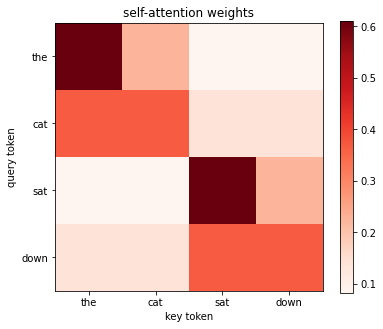

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(self_weights[0].detach().numpy(), cmap="Reds")
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("key token")
plt.ylabel("query token")
plt.title("self-attention weights")
plt.colorbar()
plt.show()

This example is still small and artificial, but the structure is already the same as in a Transformer. Each token asks *which other tokens matter for updating my representation?* Some rows may concentrate on nearby tokens, some may spread more broadly, and some may give strong weight to the token itself. Once we combine self-attention with the multi-head idea, the model can learn several such patterns in parallel. One important issue still remains, however: self-attention by itself does not know the order of tokens.

## Positional Encoding

If we shuffle the same token vectors into a different order, self-attention still computes the same kind of matching, as it has no built-in notion of first, second, or last position. That is a serious problem for language, because order changes meaning. The usual fix in the original Transformer paper is simple: before applying attention, add a position-dependent vector to each token embedding. If the token embedding at position $i$ is $x_i$ and the positional vector is $p_i$, then the actual input to the Transformer layer is $z_i = x_i + p_i$. Here, the vector $x_i$ tells the model *what* the token is, and the vector $p_i$ tells it *where* the token is. Adding them keeps the representation size unchanged, which is convenient because attention layers can then use the same dimension throughout the model.

In [17]:
# Sequence: "The cat sat" (3 tokens, 4-dim embeddings)
X = torch.randn(1, 3, 4)

# Shuffled version: "sat The cat"
indices = [2, 0, 1]
X_shuffled = X[:, indices, :]

# Attention
attn_original = scaled_dot_product_attention(X, X, X)
attn_shuffled = scaled_dot_product_attention(X_shuffled, X_shuffled, X_shuffled)

attn_original[0], attn_shuffled[0]

(tensor([[[ 1.0770,  0.0043, -1.0836,  0.0996],
          [ 0.7956,  0.0397, -1.0368,  0.1126],
          [-1.3229,  0.1843,  0.8028,  0.4157]]]),
 tensor([[[-1.3229,  0.1843,  0.8028,  0.4157],
          [ 1.0770,  0.0043, -1.0836,  0.0996],
          [ 0.7956,  0.0397, -1.0368,  0.1126]]]))

When the sequence is shuffled, the attention output is shuffled with it. Nothing inside plain self-attention marks one vector as coming from position 1 and another as coming from position 2. So we need to inject position information explicitly. The vanilla Transformer uses a fixed *sinusoidal positional encoding*. For model dimension $d$, the encoding is defined by
$$
p_{i, 2j} = \sin\!\left(\frac{i}{10000^{2j/d}}\right), \qquad
p_{i, 2j+1} = \cos\!\left(\frac{i}{10000^{2j/d}}\right).
$$
Here $i$ is the token position and $j$ selects the coordinate pair inside the positional vector. The even coordinates use sine and the odd coordinates use cosine. Different coordinates change at different speeds. Low-frequency coordinates vary slowly across positions, while high-frequency coordinates vary more quickly. This gives each position a distinct pattern while keeping the encoding dimension the same as the token embedding dimension.

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
    The model dimension $d$ is simply the length of each token vector, for example $d=512$ means every token is represented by 512 numbers. In the formula, it is used for normalizing values. The positional encoding uses those same 512 coordinates, with different coordinate pairs assigned different wave speeds. When all of these slow and fast patterns are combined, each position receives its own numerical signature. This lets the model encode not only what a token is, but also where it appears and how far it is from other tokens.
  </p>
</div>

<div class="admonition example">
  <p class="admonition-title">Example</p>
  <p style="margin: 1em 0;">
  Take a 2D token embedding ($d=2$). Suppose the word embedding for "cat" is $x = [0.50,\ 1.00]$. Since the embedding dimension is $2$, the positional encoding must also have two coordinates so it can be added to $x$. Hence, there is one sine-cosine pair, and the encoding becomes $p_i = [\sin(i),\ \cos(i)]$. If "cat" appears at position $i=1$, then
  $$
  p_1 = [\sin(1),\cos(1)] \approx [0.84,\ 0.54].
  $$
  Adding position to meaning gives
  $$
  x + p_1 = [0.50,\ 1.00] + [0.84,\ 0.54] = [1.34,\ 1.54].
  $$
  If the same word appears later at position $i=2$, then
  $$
  p_2 = [\sin(2),\cos(2)] \approx [0.91,\ -0.42],
  $$
  so the new representation is
  $$
  x + p_2 = [0.50,\ 1.00] + [0.91,\ -0.42] = [1.41,\ 0.58].
  $$
  The word embedding $x$ is unchanged, but the final vector is different because the position is different. This is how positional encoding lets the model distinguish the same word appearing in different places in the sequence.
  </p>
</div>

In [18]:
def positional_encoding(num_positions, d_model):
    positions = torch.arange(num_positions).unsqueeze(1)
    div_term = torch.pow(10000, torch.arange(0, d_model, 2) / d_model)
    P = torch.zeros(num_positions, d_model)
    P[:, 0::2] = torch.sin(positions / div_term)
    P[:, 1::2] = torch.cos(positions / div_term)
    return P

P = positional_encoding(20, 16)
P[:4, :8]

tensor([[ 0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.3110,  0.9504,  0.0998,  0.9950,  0.0316,  0.9995],
        [ 0.9093, -0.4161,  0.5911,  0.8066,  0.1987,  0.9801,  0.0632,  0.9980],
        [ 0.1411, -0.9900,  0.8126,  0.5828,  0.2955,  0.9553,  0.0947,  0.9955]])

We can now add positional encodings to token embeddings exactly as in $z_i = x_i + p_i$. The next cell uses a very simple embedding matrix so that the effect is easy to read numerically. The token information is still there, but now each position receives an extra offset that depends only on where the token appears in the sequence.

In [19]:
X_tokens = torch.tensor([
    [1.0, 0.5, 0.0, 0.2, 0.0, 0.0],
    [0.8, 0.1, 0.0, 0.3, 0.0, 0.0],
    [0.9, 0.2, 0.0, 0.4, 0.0, 0.0],
    [1.0, 0.5, 0.0, 0.2, 0.0, 0.0],
])

Z = X_tokens + positional_encoding(X_tokens.size(0), X_tokens.size(1))
Z

tensor([[ 1.0000,  1.5000,  0.0000,  1.2000,  0.0000,  1.0000],
        [ 1.6415,  0.6403,  0.0464,  1.2989,  0.0022,  1.0000],
        [ 1.8093, -0.2161,  0.0927,  1.3957,  0.0043,  1.0000],
        [ 1.1411, -0.4900,  0.1388,  1.1903,  0.0065,  1.0000]])

After this addition, two identical token embeddings placed at different positions would no longer look identical to the model (see the first and fourth tokens above). That is exactly the point. Self-attention is still responsible for deciding which tokens should interact, but positional encoding makes sure the model can also tell where those tokens are.

## Positionwise Feed-Forward Networks

So far we have built the attention side of the Transformer. But a Transformer layer is not made of attention alone. In the original architecture, each layer also contains a *positionwise feed-forward network*, and each sublayer is wrapped by a residual connection followed by [layer normalization](../05_cnn_architectures/#batch-normalization). Attention decides which tokens should exchange information, the feed-forward network then processes each token representation separately. So after tokens look at one another through attention, each position goes through the same small multilayer perceptron which refines representations. If the input at position $i$ is $x_i$, the usual Transformer feed-forward step is
$$
\operatorname{FFN}(x_i)=W_2\,\sigma(W_1 x_i+b_1)+b_2.
$$
This is just a two-layer neural network applied to one token vector at a time. The same weights are reused at every position, which is why it is called *positionwise*. Before defining the feed-forward network as a reusable module, let us first make the idea concrete with a small tensor. The next cell applies the same two-layer transformation to every position in a short sequence. The important thing to notice is that different positions do not interact inside this step. Each row is transformed separately, but the same learned rule is used for every row.

In [20]:
X = torch.tensor([[
    [1.0, 0.5, 0.0, 0.0],
    [0.8, 0.1, 0.0, 0.0],
    [0.9, 0.2, 0.0, 0.0],
]])

W1 = torch.tensor([
    [0.5, -0.3, 0.2, 0.1],
    [0.0, 0.4, 0.6, -0.2],
    [0.3, 0.1, -0.5, 0.7],
    [-0.2, 0.2, 0.1, 0.0],
    [0.1, -0.4, 0.3, 0.5],
    [0.6, 0.0, -0.1, 0.2],
])

b1 = torch.tensor([0.1, -0.2, 0.0, 0.1, 0.0, -0.1])

W2 = torch.tensor([
    [0.4, -0.2, 0.1, 0.0, 0.3, 0.2],
    [-0.1, 0.5, 0.2, 0.3, -0.2, 0.1],
    [0.0, 0.1, 0.6, -0.3, 0.2, 0.4],
    [0.2, 0.0, -0.2, 0.5, 0.1, -0.1],
])

b2 = torch.tensor([0.0, 0.1, -0.1, 0.0])

hidden = torch.relu(X @ W1.T + b1)
Y = hidden @ W2.T + b2

X.shape, hidden.shape, Y.shape

(torch.Size([1, 3, 4]), torch.Size([1, 3, 6]), torch.Size([1, 3, 4]))

The input tensor has shape `(batch_size, num_steps, d_model)` and the output has the same first two dimensions. Only the feature dimension changes inside the hidden layer and then returns to the original width. This is exactly what we want. Attention mixes information across positions, while the feed-forward network reshapes information within each position. The next cell turns this into a small PyTorch module. It is just a two-layer MLP with a ReLU in the middle, applied to the last dimension of the input tensor.

In [21]:
class PositionwiseFFN(torch.nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = torch.nn.Linear(d_model, d_ff)
        self.linear2 = torch.nn.Linear(d_ff, d_model)

    def forward(self, X):
        return self.linear2(torch.relu(self.linear1(X)))

ffn = PositionwiseFFN(d_model=4, d_ff=8)
Y = ffn(X)
Y.shape

torch.Size([1, 3, 4])

## Add and Norm

The feed-forward network is only one half of the remaining Transformer block. The other half is the *Add & Norm* step. In the original Transformer, each sublayer is wrapped in the pattern
$$
\operatorname{AddNorm}(x, \operatorname{Sublayer}(x))
=
\operatorname{LayerNorm}\bigl(x + \operatorname{Sublayer}(x)\bigr).
$$
This formula has two parts. The addition $x+\operatorname{Sublayer}(x)$ is a [residual connection](../05_cnn_architectures/#residual-network). It lets the original input flow forward more directly, which helps optimization. Then `LayerNorm` rescales the result featurewise so that the representation stays numerically well behaved. The next cell shows this pattern with a small tensor. We first create a sublayer output, then add it back to the input, and finally normalize the result along the feature dimension.

In [22]:
layer_norm = torch.nn.LayerNorm(4)

sublayer_out = ffn(X)
residual_sum = X + sublayer_out
normalized = layer_norm(residual_sum)

X, residual_sum, normalized

(tensor([[[1.0000, 0.5000, 0.0000, 0.0000],
          [0.8000, 0.1000, 0.0000, 0.0000],
          [0.9000, 0.2000, 0.0000, 0.0000]]]),
 tensor([[[0.7950, 0.8551, 0.2477, 0.1848],
          [0.5615, 0.4827, 0.2051, 0.2255],
          [0.6711, 0.5925, 0.2205, 0.2327]]], grad_fn=<AddBackward0>),
 tensor([[[ 0.8967,  1.0931, -0.8920, -1.0978],
          [ 1.2353,  0.7299, -1.0482, -0.9170],
          [ 1.1824,  0.7984, -1.0203, -0.9605]]],
        grad_fn=<NativeLayerNormBackward0>))

The three tensors should be read in order. `X` is the incoming representation, `residual_sum` is the result after adding the sublayer output back to it, and `normalized` is the final output after layer normalization. The residual step means the sublayer is learning a correction to the input rather than a completely new representation from scratch. The normalization step keeps the scale under control at each position. We can now package this into one small module, just as we did for the feed-forward network.

In [23]:
class AddNorm(torch.nn.Module):
    def __init__(self, d_model, dropout=0.0):
        super().__init__()
        self.dropout = torch.nn.Dropout(dropout)
        self.layer_norm = torch.nn.LayerNorm(d_model)

    def forward(self, X, Y):
        return self.layer_norm(X + self.dropout(Y))

add_norm = AddNorm(d_model=4, dropout=0.0)
Z = add_norm(X, ffn(X))
Z.shape

torch.Size([1, 3, 4])

## Transformer Architecture

At this stage we have assembled the core mechanisms of attention: queries, keys, values, scaled dot-product attention, multi-head attention, self-attention, positional encoding, the position-wise feed-forward network, and the add & norm block. What remains is to place these components into the larger system known as the Transformer architecture. The original model ([Vaswani et al., 2017](https://arxiv.org/abs/1706.03762)) was designed first and foremost for machine translation and more generally for sequence-to-sequence tasks: one sequence is given as input, and another sequence must be produced as output. For example, an English sentence is read and a Azerbaijani sentence is generated. That goal explains why the original Transformer contains both an encoder and a decoder.

<figure>
  <img src="../../assets/images/transformer/transformer.svg" alt="Transformer Architecture" style="max-width: 100%; height: auto;">
  <figcaption style="margin-top: 0.5em; font-size: 0.9em; opacity: 0.85;">
    Transformer Architecture. ~ Zhang et al., <a href="https://d2l.ai/chapter_attention-mechanisms-and-transformers/multihead-attention.html">Dive into Deep Learning</a>, <a href="https://d2l.ai/_images/transformer.svg">Fig. 11.7.1</a>.
    <a href="https://creativecommons.org/licenses/by-sa/4.0/">CC BY-SA 4.0</a>.
  </figcaption>
</figure>

The *encoder* is responsible for understanding the input sequence. It receives all source tokens at once, enriches them through self-attention, and outputs contextualized representations in which each token already contains information from the rest of the input sentence. In other words, the encoder converts raw token embeddings into a learned memory of the source text.

The *decoder* has a different job. It must generate the target sequence one token at a time. At every step it uses masked self-attention to look only at tokens generated so far, and it also uses **cross-attention** to consult the encoder output whenever source information is needed. So the encoder builds representations of what was given, while the decoder uses those representations to produce what should come next. This division of labor is not mandatory in all Transformer systems. It depends on the purpose of the model.

If the task is mainly *understanding* a sequence rather than generating one, an encoder-only design is often sufficient. This is the idea behind BERT ([Devlin et al., 2018](https://arxiv.org/abs/1810.04805)). BERT (Bidirectional Encoder Representations from Transformers) keeps the encoder stack and removes the [autoregressive](../../notebooks/06_rnn_sequential#autoregressive-modeling) decoder. Because there is no **causal mask**, each token may attend to tokens on both the left and the right. That bidirectional context makes encoder models especially useful for classification, search, sentence similarity, named entity recognition, extractive question answering, and other tasks where the goal is to produce representations rather than free-form text. You can think of BERT answering questions such as: *What does this sentence mean? Which label fits it? Which span answers the query?*

If the task is mainly *generation*, a decoder-only design is often more natural. This is the idea behind the GPT ([Radford et al., 2018](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf)). GPT (Generative Pre-trained Transformer) keeps the causal decoder pathway and omits the separate encoder. Each new token is predicted from the tokens that came before it. During training, the model learns next-token prediction over large text corpora. During inference, generation continues autoregressively: the model writes one token, appends it to the context, and predicts the next. This design is highly effective for dialogue, summarization, coding, reasoning traces, and open-ended text generation. You can think of GPT answering the question: *Given everything so far, what should come next?*

The first full Transformer layer we study next will usually be the encoder block, since it is the simplest complete block: multi-head self-attention, followed by a feed-forward network, each wrapped with residual connections and normalization. Once that block is clear, the decoder block is a small extension: it adds causal masking and an extra cross-attention stage that reads from the encoder output.

## Transformer Block

Instead of the full encoder-decoder Transformer, we will build a decoder-only Transformer block. This lets us focus on the part that matters for autoregressive language modelin, and keeps the architecture simpler, because we can postpone encoder-decoder attention and first understand how masked self-attention, residual connections, and feed-forward layers work together inside a single block.

We start with the simplest question: if a sequence of token embeddings enters the decoder block, what should an attention head do with them? It should produce a new representation for each position by comparing that position with the earlier positions in the sequence and then mixing information from them. To make this happen, the same input embeddings are transformed into three different views: queries, keys, and values. These are not three different inputs. They are three learned projections of the same sequence, each serving a different role inside attention.

Suppose the input to the block is a matrix $X \in \mathbb{R}^{B \times T \times d_{\text{model}}}$, where $B$ is the batch size, $T$ is the sequence length, and $d_{\text{model}}$ is the embedding size. An attention head does not work with $X$ directly. It first applies three learned linear maps to produce
$$
Q = XW_Q,\quad K = XW_K,\quad V = XW_V.
$$
Here $Q$, $K$, and $V$ have the same batch and sequence dimensions as $X$, but their last dimension is usually a smaller head dimension $d_{\text{head}}$. This is the first concrete step of attention: from one sequence representation, we create three projected versions that will later be used to decide where to attend and what information to pass forward.

In [24]:
class AttentionHeadProjections(torch.nn.Module):
    def __init__(self, d_model, d_head):
        super().__init__()
        self.q_proj = torch.nn.Linear(d_model, d_head, bias=False)
        self.k_proj = torch.nn.Linear(d_model, d_head, bias=False)
        self.v_proj = torch.nn.Linear(d_model, d_head, bias=False)

    def forward(self, x):
        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)
        return Q, K, V

In [25]:
X = torch.randn(2, 5, 8)

proj = AttentionHeadProjections(d_model=8, d_head=4)
Q, K, V = proj(X)

X.shape, Q.shape, K.shape, V.shape

(torch.Size([2, 5, 8]),
 torch.Size([2, 5, 4]),
 torch.Size([2, 5, 4]),
 torch.Size([2, 5, 4]))

The shapes show exactly what these projections did. The input $X$ has shape $(B, T, d_{\text{model}})$, while $Q$, $K$, and $V$ each have shape $(B, T, d_{\text{head}})$. So nothing changed in the batch dimension or in the sequence length. We still have one vector per token position. Only the feature dimension changed: each token embedding in $d_{\text{model}}$ dimensions was projected into a smaller space of size $d_{\text{head}}$. This is the space in which one attention head will compare tokens and exchange information. The next step is to use $Q$ and $K$ to compute attention scores, which tell us how strongly each position should attend to the earlier positions in the sequence. Earlier, we saw how attention uses $Q$ and $K$ to compute scores, applies a mask when needed, normalizes with softmax, and then uses the resulting weights to mix the value vectors $V$. We now wrap that same logic into a reusable self-attention head.

In [26]:
class SelfAttentionHead(torch.nn.Module):
    def __init__(self, d_model, d_head):
        super().__init__()
        self.q_proj = torch.nn.Linear(d_model, d_head, bias=False)
        self.k_proj = torch.nn.Linear(d_model, d_head, bias=False)
        self.v_proj = torch.nn.Linear(d_model, d_head, bias=False)

    def forward(self, x, mask=None):
        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)
        out, attn_weights = scaled_dot_product_attention(Q, K, V, mask)
        return out, attn_weights

We can now test one self-attention head inside the decoder setting. We had already seen masking. The purpose of *causal mask* is to prevent position $i$ from attending to positions that come after it. So even though the attention code itself is general, the decoder becomes autoregressive by passing a lower-triangular mask into the head. The result is still one output vector per token position, but each output is now built only from information available up to that position.

In [27]:
X = torch.randn(2, 5, 8)

T = X.shape[1]
mask = torch.tril(torch.ones(T, T, dtype=torch.bool))

head = SelfAttentionHead(d_model=8, d_head=4)
head_output, attn_weights = head(X, mask=mask)

X.shape, mask.shape, head_output.shape, attn_weights.shape

(torch.Size([2, 5, 8]),
 torch.Size([5, 5]),
 torch.Size([2, 5, 4]),
 torch.Size([2, 5, 5]))

A single head already performs masked self-attention, but it can look at the sequence only through one learned set of projections. We had already seen that the Transformer uses several heads in parallel. Each head gets its own $W_Q$, $W_K$, and $W_V$, so different heads can focus on different kinds of relationships between tokens. After that, their outputs are concatenated and projected back to $d_{\text{model}}$. So multi-head attention is several self-attention heads running side by side and then merged into one representation again.

In [28]:
class MultiHeadAttention(torch.nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads

        self.heads = torch.nn.ModuleList(
            [SelfAttentionHead(d_model, self.d_head) for _ in range(num_heads)]
        )
        self.out_proj = torch.nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, mask=None):
        head_outputs = []
        attn_weights_all = []

        for head in self.heads:
            out, attn_weights = head(x, mask=mask)
            head_outputs.append(out)
            attn_weights_all.append(attn_weights)

        out = torch.cat(head_outputs, dim=-1)
        out = self.out_proj(out)
        return out, attn_weights_all

We can now test the full multi-head module. The input still has shape $(B, T, d_{\text{model}})$, and the final output should have exactly the same shape, because the decoder block must pass a representation of the same size to the next sublayer. Inside the module, each head produces an output of shape $(B, T, d_{\text{head}})$. These are concatenated along the feature dimension to recover $(B, T, d_{\text{model}})$, and then a final linear projection mixes information across heads.

In [29]:
X = torch.randn(2, 5, 8)

T = X.shape[1]
mask = torch.tril(torch.ones(T, T, dtype=torch.bool))

mha = MultiHeadAttention(d_model=8, num_heads=2)
mha_output, attn_weights_all = mha(X, mask=mask)

X.shape, mha_output.shape, len(attn_weights_all), attn_weights_all[0].shape

(torch.Size([2, 5, 8]), torch.Size([2, 5, 8]), 2, torch.Size([2, 5, 5]))

At this point, the only new part we wanted to build slowly was masked multi-head self-attention. The remaining pieces of the decoder block are already familiar from earlier: a residual connection with layer normalization, followed by a position-wise feed-forward network, and then another residual connection with layer normalization. So instead of reimplementing those again, we now reuse the existing modules and combine them with our new causal multi-head attention module.

In [30]:
class TransformerDecoderBlock(torch.nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.addnorm1 = AddNorm(d_model, dropout)
        self.ffn = PositionwiseFFN(d_model, d_ff)
        self.addnorm2 = AddNorm(d_model, dropout)

    def forward(self, x, mask=None):
        attn_out, _ = self.attention(x, mask=mask)
        x = self.addnorm1(x, attn_out)
        ffn_out = self.ffn(x)
        x = self.addnorm2(x, ffn_out)
        return x

We can now test the full decoder block. The input and output should both have shape $(B, T, d_{\text{model}})$, because the block transforms the sequence representation but does not change its overall size. The causal mask is still what makes this a decoder block rather than an encoder block.

In [31]:
X = torch.randn(2, 5, 8)

T = X.shape[1]
mask = torch.tril(torch.ones(T, T, dtype=torch.bool))

decoder_block = TransformerDecoderBlock(d_model=8, num_heads=2, d_ff=16, dropout=0.0)
Y = decoder_block(X, mask=mask)

X.shape, Y.shape

(torch.Size([2, 5, 8]), torch.Size([2, 5, 8]))

## Training Transformer

So far, we built the main component of the model: the decoder block with masked multi-head self-attention. The next step is to place these blocks inside a full decoder-only Transformer and train it on a real next-token prediction task. In this section, we will move from the block level to the full model level: token ids will first be mapped to embeddings, positional information will be added, and the sequence will pass through several decoder blocks stacked on top of each other. The final hidden states will then be projected to vocabulary logits, so that for each position the model predicts which token should come next.

This is a natural setting for a decoder-only Transformer. During training, the model receives a sequence of tokens as input and tries to predict the shifted sequence of target tokens. Because of the causal mask, each position can use only the tokens to its left when making that prediction. After building the model, we will prepare the TinyShakespeare text, create batches of input-target sequences, train the network with cross-entropy loss, and finally use the trained model for text generation.

In [32]:
class TransformerDecoder(torch.nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, dropout=0.0):
        super().__init__()
        self.d_model = d_model
        self.token_embed = torch.nn.Embedding(vocab_size, d_model)
        self.layers = torch.nn.ModuleList([
            TransformerDecoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.output_layer = torch.nn.Linear(d_model, vocab_size)

    def add_position(self, X):
        scale = self.d_model ** 0.5
        P = positional_encoding(X.size(1), X.size(2)).to(X.device).unsqueeze(0)
        return scale * X + P

    def _causal_mask(self, T, device):
        return torch.tril(torch.ones(T, T, dtype=torch.bool, device=device))

    def forward(self, tokens):
        X = self.add_position(self.token_embed(tokens))
        T = tokens.size(1)
        mask = self._causal_mask(T, tokens.device)

        for layer in self.layers:
            X = layer(X, mask=mask)

        logits = self.output_layer(X)
        return logits

Before we can train the model, we need to turn raw text into token sequences. We will choose a dataset, build a vocabulary from its characters, and then encode the full text as a sequence of integer token ids. After that, we will split the sequence into input-target pairs for next-token prediction. The input sequence will contain tokens $x_1, x_2, \dots, x_T$, and the target sequence will be the same text shifted one position to the left, so that the model learns to predict the next character at each step. We will treat our dataset as a character-level dataset, which keeps the preprocessing simple and matches the next-token prediction setup directly: at each position, the model sees a sequence of previous characters and learns to predict the next one.

In [33]:
import requests

def load_text(source="tinyshakespeare"):
    if source == "tinyshakespeare":
        return requests.get(
            "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
        ).text
    return open(source, "r", encoding="utf-8").read()

In [34]:
text = load_text("tinyshakespeare")
# text = load_text("./data/tinyhuseynjavid.txt")

chars = sorted(set(text))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

def encode(s):
    return [stoi[ch] for ch in s]

def decode(ids):
    return "".join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)

len(text), vocab_size, data.shape

(1115394, 65, torch.Size([1115394]))

It is worth checking a small slice of the text before moving on. This is only a sanity check: we want to confirm that the file loaded correctly and get a quick sense of the character-level data the model will see.

In [35]:
len(text), len(chars), data.shape

(1115394, 65, torch.Size([1115394]))

In [36]:
print(text[:200])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


We now turn the full character stream into training examples. For next-token prediction, each input sequence has length $T$, and the target sequence is the same window shifted one position to the left. So if the input is $[x_1, x_2, \dots, x_T]$, then the target is $[x_2, x_3, \dots, x_{T+1}].$ This we saw in our previous notebook.

In [37]:
BLOCK_SIZE = 64

X = data.unfold(0, BLOCK_SIZE, 1)[:-1]
Y = data[1:].unfold(0, BLOCK_SIZE, 1)

X.shape, Y.shape

(torch.Size([1115330, 64]), torch.Size([1115330, 64]))

The full text is now represented as many overlapping input-target pairs. Each row of $X$ is a block of length $T$, and the corresponding row of $Y$ is the same block shifted by one position. We can now wrap these tensors in a dataloader and train the model with ordinary mini-batch gradient descent.

In [38]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64

train_dataset = TensorDataset(X, Y)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

len(train_dataset), len(train_loader)

(1115330, 17427)

We now place several decoder blocks inside one decoder-only Transformer. The model takes token ids as input, maps them to embeddings, adds positional information, passes them through stacked decoder blocks, and finally produces vocabulary logits for next-token prediction.

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

D_MODEL = 128
NUM_HEADS = 4
D_FF = 512
NUM_LAYERS = 4
DROPOUT = 0.1

model = TransformerDecoder(
    vocab_size=vocab_size,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(device)

sum(p.numel() for p in model.parameters())

807745

Before training, it is worth to see if we can use the model autoregressively. We begin with a short prompt, run it through the Transformer, sample the next token from the last output distribution, append it to the sequence, and repeat. As we haven't trained the model, our Transformer parameters are initialized randomly. We will hopefully see better results after training the model.

In [40]:
@torch.no_grad()
def generate(model, start_text, max_new_tokens, temperature=1.0):
    model.eval()

    tokens = torch.tensor([encode(start_text)], dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        x = tokens[:, -BLOCK_SIZE:]
        logits = model(x)
        next_token_logits = logits[:, -1, :] / temperature
        probs = torch.softmax(next_token_logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        tokens = torch.cat([tokens, next_token], dim=1)

    return decode(tokens[0].tolist())

print(generate(model, start_text="ROMEO:\n", max_new_tokens=400, temperature=0.8))

ROMEO:

Xm-sY&Rj'gciAGyJD.K-&aFz3i$ptgmbJypsr!iMGABEmsgfHhFlvcBsiUhdjcA:DBWAEFWCuizmAdtkHNcupCVA!P-eQadUIurKmusYtVfhKUV?bQ'qJ&QqLb

rtpCdQTfJ;33v: LKcuOXp,,ij qCqjnGeQQVAzyf'aWWgKrH??iX:i,wDt
Gzts zb!?uQ-cQ'hK;ZHCCVighsWghRq.RgQt$ CWfQPiQ,uWCj-Yz
sOQBszKV:&3:$&sSFIpHk;BZBASIdNKoZG.AZmSCw;j VKha.D;ymdebEqVRiEth? 3c x?nL
KMTTG
VtdRh&JhTPT RiTVAI3aj'r
QASs;WtJ!Y3wjF?zdjDhIOQtphWOas!SFNMXgmgf$CeiMEq$lApwbP!&


Worth noting is the `temperature` parameter controls how random the sampling is. When the temperature is smaller than $1$, the model becomes more conservative and prefers higher-probability tokens more strongly. When the temperature is larger than $1$, the output becomes more random and diverse. So lower temperature usually gives safer and more repetitive text, while higher temperature gives more surprising but less stable text.

Finally, we will train our Transformer model with the usual training logic that we have seen over and over again starting from the [backpropagation](../../notebooks/01_backprop) lecture. Note that the learning rate of `3-e4` is often considered to be golden default.

In [41]:
lr = 3e-4
epochs = 5

optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
criterion = torch.nn.CrossEntropyLoss()

In [42]:
for e in range(epochs):
    model.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits.view(-1, vocab_size), yb.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"epoch {e + 1}/{epochs}: loss = {total_loss / len(train_loader):.4f}")

epoch 1/5: loss = 1.6121
epoch 2/5: loss = 1.3986
epoch 3/5: loss = 1.3450
epoch 4/5: loss = 1.3143
epoch 5/5: loss = 1.2940


Once the training is finished, it is worth seeing whether our model has improved or not.

In [43]:
print(generate(model, start_text="ROMEO:\n", max_new_tokens=400, temperature=0.8))

ROMEO:
Thou were a unjust in the will be safety.

POLIXENES:
My lord,
Would have been all of the desire on me;
Or else it be so good
To me and fever doth deceit.

ARCHIDAMUS:
Away, I am bring for thee deputy, to see him
Of her loves to set.
Sir, now I have died to see him, have made here,
As if love a todd widow the deceived of his deer.
Dread parting and me to my true wooing,
And every trespected in the


We now have a complete decoder-only Transformer pipeline. Starting from raw text, we built token sequences for next-token prediction, passed them through stacked masked self-attention blocks, trained the model on our text corpus, and then used it autoregressively to generate new text. Even though this is a small character-level model, the main logic is already the same as in larger decoder-only language models.

<div class="admonition success">
  <p class="admonition-title">Exercise</p>
  <p style="margin: 1em 0;">
    Extend this decoder-only Transformer into a full encoder-decoder Transformer. Reuse the ideas developed in this notebook, but now separate the model into two parts: an encoder that reads the source sequence without causal masking, and a decoder that keeps causal self-attention while also attending to the encoder output through cross-attention.
  </p>
</div>

Having built and trained the core Transformer ourselves, we are now in a good position to step back and look at some of the major directions that followed from it. We will briefly discuss vision-oriented variants, and other practical ideas before concluding our notebook.

## KV Cache

So far, we treated the decoder as if it processes the whole prefix from scratch each time. That is fine for training, where we feed an entire sequence in parallel, but it is inefficient during autoregressive generation. Suppose we already generated tokens $x_1, x_2, \dots, x_t$ and now want to produce $x_{t+1}$. A naive implementation would run the Transformer again on the full prefix just to obtain the next-token distribution. Then, after sampling $x_{t+1}$, it would run again on $[x_1, x_2, \dots, x_t, x_{t+1}]$, recomputing many of the same hidden states and attention projections. This is correct, but wasteful.

In a decoder-only Transformer, the old tokens do not change when a new token is appended. So the key and value vectors already computed for earlier positions can be stored and reused. This stored state is called the *KV cache*. Instead of recomputing keys and values for the whole prefix at every generation step, we compute them once, save them, and then only compute the new key and value for the newly added token. The new query can then attend to the cached keys and values from all previous positions.

This changes inference much more than it changes training. During training, we usually process many positions in parallel, so caching is not the main concern. During generation, however, tokens are produced one by one, and KV caching becomes essential for efficiency. Without a cache, generation repeatedly recomputes old work. With a cache, each new step reuses what was already computed in earlier steps.

A more recent direction is to reduce inference cost as well, by shrinking the KV cache. DeepSeek-V2 introduced *Multi-head Latent Attention* ([DeepSeek-AI, 2024](https://arxiv.org/abs/2405.04434))(https://arxiv.org/abs/2405.04434). The main idea is to compress key-value information into a lower-dimensional latent form, so that autoregressive decoding uses less cache memory while still preserving strong model quality. This matters because, in long-context generation, memory pressure often comes not only from the attention matrix during training but also from the growing KV cache during inference.

## Improving Attention

Standard self-attention is powerful, but it becomes expensive on long sequences because each token attends to every other token. If the sequence length is $T$, then the attention score matrix has shape $T \times T$, so both compute and memory grow on the order of $T^2$. In practice, this memory footprint is one of the main bottlenecks, because storing scores and related intermediate tensors quickly becomes costly as context length grows.

One response is to change the attention pattern itself. Local or windowed attention lets each token attend mainly to nearby positions, while sparse variants also keep a small number of longer-range or global connections. The goal is to reduce the quadratic cost while still allowing useful information to move through the sequence. For example, Longformer ([Beltagy et al., 2020](https://arxiv.org/abs/2004.05150)) combines sliding-window local attention with a small set of global tokens. This keeps the cost closer to linear in sequence length while still letting selected positions communicate broadly across the document.

Another response is to change the computation rather than the connectivity pattern. Linear-attention methods try to avoid explicitly forming the full $T \times T$ attention matrix, replacing it with kernel-based or approximated computations whose cost grows roughly linearly with sequence length. Examples include Linear Transformers ([Katharopoulos et al., 2020](https://arxiv.org/abs/2006.16236)) and Performers ([Choromanski et al., 2020](https://arxiv.org/abs/2009.14794)). These methods can be much cheaper on long contexts, but they also modify the original softmax attention mechanism and may introduce approximation tradeoffs.

It is possible to also preserve exact softmax attention but execute it more efficiently. FlashAttention ([Dao et al., 2022](https://arxiv.org/abs/2205.14135)) does not change which tokens attend to which others. Instead, it reorganizes the computation to reduce memory traffic between different levels of GPU memory. FlashAttention is bascially an exact, IO-aware attention algorithm that often gives major practical speed and memory improvements.

## Vision Transformer

So far, we used the Transformer for text, where the input already comes as an ordered sequence of tokens. In vision, however, the input is an image rather than a sentence. The key idea of the Vision Transformer ([Dosovitskiy et al., 2021](https://arxiv.org/abs/2010.11929)) is to turn the image into a sequence first and then apply a standard Transformer encoder to that sequence. Instead of [convolving](../../notebooks/03_cnn_torch) over the image, we split it into small non-overlapping patches, flatten each patch, project it into the model dimension, add positional information, and treat the resulting patch embeddings as tokens.

<figure>
  <img src="../../assets/images/transformer/vit.svg" alt="Vision Transformer Architecture" style="max-width: 100%; height: auto;">
  <figcaption style="margin-top: 0.5em; font-size: 0.9em; opacity: 0.85;">
    The vision Transformer architecture. In this example, an image is split into nine patches. A special <code>&lt;cls&gt;</code> token and the nine flattened image patches are transformed via patch embedding and Transformer encoder blocks into ten representations. The <code>&lt;cls&gt;</code> representation is further transformed into the output label. ~ Zhang et al., <a href="https://d2l.ai/chapter_attention-mechanisms-and-transformers/vision-transformer.html">Dive into Deep Learning</a>, <a href="https://d2l.ai/_images/vit.svg">Fig. 11.8.1</a>.
    <a href="https://creativecommons.org/licenses/by-sa/4.0/">CC BY-SA 4.0</a>.
  </figcaption>
</figure>

If an image has shape $(H, W, C)$ and the patch size is $P \times P$, then the number of patches is $N = \frac{HW}{P^2}$, assuming that $H$ and $W$ are divisible by $P$. Each patch is flattened into a vector of length $P^2 C$ and then mapped by a learned linear projection into a vector in $\mathbb{R}^{d_{\text{model}}}$. In this way, the image becomes a sequence of $N$ patch tokens, much like a sentence becomes a sequence of word tokens.

Vision Transformer (ViT) matters because it makes the Transformer look less like a model for language alone (which was its original purpose) and more like a general architecture for tokenized data. Once the input can be represented as a sequence of vectors, the same basic machinery can be applied in many settings. In language, the tokens are words or subwords. In vision, the tokens can be image patches. In other settings, they may be audio segments, video patches, multimodal inputs, or even sets of learned latent tokens. In this sense, the Transformer is less defined by the nature of the original data than by the idea of representing that data as interacting tokens.

At the same time, plain ViT also reveals an important weakness of the Transformer. Unlike a convolutional neural network, it does not begin with a strong built-in bias toward locality, translation structure, or multi-scale image processing. A CNN already assumes that nearby pixels should be processed together and that local patterns matter. ViT has to learn much more of this from data. For this reason, it Transformers are often more data-hungry than classical convolutional architectures. In practice, ViT became especially successful when paired with large-scale pretraining, where enough data is available for the model to learn these useful visual regularities.

Another notable feature of ViT is the special $[\mathrm{CLS}]$ token. This is a learned vector appended to the patch sequence before entering the Transformer. During self-attention, it can gather information from all image patches, and its final representation is then used for classification. Its role is similar in spirit to [global average pooling](../../notebooks/05_cnn_architectures/#network-in-network) in a CNN, because both aim to produce one vector that summarizes the whole image. However, they are not the same operation. GAP layer is fixed: it simply averages spatial features. The $[\mathrm{CLS}]$ token is learned and interacts with the patch tokens through attention, so the model can decide how information from different regions should contribute to the final summary.

A natural next step was to make Transformers more suitable for vision structure itself. One influential answer is the Swin Transformer ([Liu et al., 2021](https://arxiv.org/abs/2103.14030)). Instead of applying global self-attention over all patches at once, Swin restricts attention to local windows and then shifts those windows between layers, so information can still flow across the image over depth. It also builds a hierarchical representation, more like a CNN feature pyramid, by merging patches as the network goes deeper. This makes the model more efficient and better aligned with the multi-scale nature of visual tasks such as detection and segmentation. In this way, Swin can be seen as a step from the plain, sequence-based ViT toward a Transformer architecture that is more explicitly adapted to the structure of images.

## Scaling Laws

Once Transformers proved effective across language and vision, another question became unavoidable: _what happens as we make them larger and train them longer?_ A major empirical answer came from scaling laws, especially in language modeling ([Kaplan et al., 2020](https://arxiv.org/abs/2001.08361)). The central observation is that model performance often improves in a smooth and predictable way as we increase three main ingredients: model size, dataset size, and compute. In other words, progress is not only about inventing new architectural tricks. It is also about understanding how performance changes when we scale the ingredients of training.

This was important because it shifted part of deep learning from trial-and-error engineering toward a more empirical science of scaling. If loss decreases according to a relatively regular trend as parameters or data increase, then we can reason about tradeoffs more systematically. A small model trained on too much data may underuse the data. A huge model trained on too little data may underuse the model capacity. So scaling laws suggest that good performance does not come from maximizing a single quantity in isolation, but from balancing model size, data, and training compute.

A simplified way to think about this is that validation loss often behaves approximately like a power law. If $N$ is the number of parameters, $D$ is the amount of data, and $C$ is the available compute, then the loss does not usually drop linearly with these quantities. Instead, it tends to decrease more gradually, with diminishing returns. Early scaling work emphasized that larger models trained on larger datasets continue to improve in a fairly regular way, and this helped justify the move toward very large Transformer-based models.

Later work refined this. [Hoffmann et al. (2022)](https://arxiv.org/abs/2203.15556) argued that many [large language models](https://en.wikipedia.org/wiki/Large_language_model) (LLMs) had been undertrained relative to their size. Their Chinchilla result suggested that, for a fixed compute budget, it can be better to train a somewhat smaller model on more data rather than a much larger model on too little data. This sharpened scaling laws by showing that the balance between parameters and data matters more carefully than some earlier practices assumed.

These ideas were reflected in the development of LLMs such as GPT family ([Radford et al., 2019](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf), [Brown et al., 2020](https://arxiv.org/abs/2005.14165)). Hence, Transformer performance is tied to a scaling regime. Architecture still matters, but once a strong architecture is in place, a great deal of progress comes from how effectively we scale parameters, data, and compute together. This is one reason why modern Transformer research is not only about new layers or attention variants, but also about training efficiency, data quality, inference cost, and deployment constraints.

## Conclusion

In this notebook, we developed the Transformer step by step. We began with the basic attention mechanism itself, including queries, keys, values, similarity scores, masking, and the way attention mixes token representations, then moved from these ideas to the main Transformer components and their organization into larger architectures. We built and trained a decoder-only Transformer, and used it for autoregressive text generation. After that, we looked at how Transformers extend beyond language to vision and other areas and examined several themes that shape modern Transformer research in practice, including scaling laws, KV cache, and a range of efficient-attention ideas.